In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import TextVectorization, Dense, Dropout
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [2]:
texts = [
    "I love this movie",
    "This film was amazing",
    "The acting was excellent",
    "I really enjoyed the story",
    "The movie was fantastic",
    "What a wonderful film",
    "The characters were great",
    "I liked this movie very much",
    "The story was interesting",
    "This was a brilliant movie",
    "The film made me happy",
    "I would watch this again",
    "The movie was very enjoyable",
    "The performance was impressive",
    "This is one of my favorite films",

    "I hate this movie",
    "This film was terrible",
    "The acting was very bad",
    "I did not enjoy the story",
    "The movie was boring",
    "What a horrible film",
    "The characters were annoying",
    "I disliked this movie",
    "The story was disappointing",
    "This was a very poor movie",
    "The film made me unhappy",
    "I would never watch this again",
    "The movie was not enjoyable",
    "The performance was awful",
    "This is one of the worst films"
]

# 1 = Positive, 0 = Negative
labels = [
    1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

df


,text,label
0,I love this movie,1
1,This film was amazing,1
2,The acting was excellent,1
3,I really enjoyed the story,1
4,The movie was fantastic,1
5,What a wonderful film,1
6,The characters were great,1
7,I liked this movie very much,1
8,The story was interesting,1
9,This was a brilliant movie,1


In [3]:
# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 80% training and 20% validation
split_index = int(len(df) * 0.8)

train_df = df[:split_index]
val_df = df[split_index:]

X_train = train_df["text"].values
y_train = train_df["label"].values

X_val = val_df["text"].values
y_val = val_df["label"].values

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 24
Validation samples: 6


In [4]:
max_tokens = 1000
output_length = 20

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=output_length
)

# Learn vocabulary only from training data
vectorizer.adapt(X_train)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))
print("Example text:", X_train[0])
print("Vectorized text:", vectorizer(X_train[0]))


Vocabulary size: 50
Example text: The movie was not enjoyable
Vectorized text: tf.Tensor([ 2  5  3 14 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0], shape=(20,), dtype=int64)


In [5]:
X_train_vec = vectorizer(np.array(X_train))
X_val_vec = vectorizer(np.array(X_val))

print("Training vector shape:", X_train_vec.shape)
print("Validation vector shape:", X_val_vec.shape)


Training vector shape: (24, 20)
Validation vector shape: (6, 20)


In [6]:
baseline_model = Sequential([
    tf.keras.layers.Embedding(
        input_dim=max_tokens,
        output_dim=16
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_baseline = baseline_model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=20,
    batch_size=4,
    verbose=1
)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.4583 - loss: 0.6940 - val_accuracy: 0.6667 - val_loss: 0.6917
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2500 - loss: 0.6943 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5417 - loss: 0.6928 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5417 - loss: 0.6927 - val_accuracy: 0.3333 - val_loss: 0.6941
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5417 - loss: 0.6926 - val_accuracy: 0.3333 - val_loss: 0.6954
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5417 - loss: 0.6920 - val_accuracy: 0.3333 - val_loss: 0.6962
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5417 - loss: 0.6918 - val_accuracy: 0.3333 - val_loss: 0.6965
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5417 - loss: 0.6916 - val_accuracy: 0.3333 - val_loss: 0.6975

In [8]:
dropout_model = Sequential([
    tf.keras.layers.Embedding(
        input_dim=max_tokens,
        output_dim=16
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_dropout = dropout_model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=20,
    batch_size=4,
    verbose=1
)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.3750 - loss: 0.6919 - val_accuracy: 0.3333 - val_loss: 0.6994
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3750 - loss: 0.6992 - val_accuracy: 0.3333 - val_loss: 0.7008
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5833 - loss: 0.6895 - val_accuracy: 0.3333 - val_loss: 0.7005
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5417 - loss: 0.6918 - val_accuracy: 0.3333 - val_loss: 0.7011
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4583 - loss: 0.6965 - val_accuracy: 0.3333 - val_loss: 0.7012
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7083 - loss: 0.6893 - val_accuracy: 0.3333 - val_loss: 0.7010
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6667 - loss: 0.6912 - val_accuracy: 0.3333 - val_loss: 0.7016
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.6959 - val_accuracy: 0.3333 - val_loss: 0.7007


In [10]:
l2_model = Sequential([
    tf.keras.layers.Embedding(
        input_dim=max_tokens,
        output_dim=16,
        embeddings_regularizer=l2(0.001)
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),
    Dense(1, activation="sigmoid")
])

l2_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

l2_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_l2 = l2_model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=20,
    batch_size=4,
    verbose=1
)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4583 - loss: 0.7222 - val_accuracy: 0.6667 - val_loss: 0.7132
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4583 - loss: 0.7174 - val_accuracy: 0.6667 - val_loss: 0.7115
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4583 - loss: 0.7135 - val_accuracy: 0.6667 - val_loss: 0.7106
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4583 - loss: 0.7105 - val_accuracy: 0.6667 - val_loss: 0.7100
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.7081 - val_accuracy: 0.3333 - val_loss: 0.7096
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6667 - loss: 0.7065 - val_accuracy: 0.1667 - val_loss: 0.7096
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7500 - loss: 0.7054 - val_accuracy: 0.1667 - val_loss: 0.7100
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6250 - loss: 0.7043 - val_accuracy: 0.1667 - val_loss: 0.7105

In [13]:
results = pd.DataFrame({
    "Model": [
        "No Regularization",
        "Dropout",
        "L2 Regularization"
    ],
    "Training Accuracy": [
        history_baseline.history["accuracy"][-1],
        history_dropout.history["accuracy"][-1],
        history_l2.history["accuracy"][-1]
    ],
    "Validation Accuracy": [
        history_baseline.history["val_accuracy"][-1],
        history_dropout.history["val_accuracy"][-1],
        history_l2.history["val_accuracy"][-1]
    ],
    "Training Loss": [
        history_baseline.history["loss"][-1],
        history_dropout.history["loss"][-1],
        history_l2.history["loss"][-1]
    ],
    "Validation Loss": [
        history_baseline.history["val_loss"][-1],
        history_dropout.history["val_loss"][-1],
        history_l2.history["val_loss"][-1]
    ]
})

results


,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,No Regularization,0.541667,0.333333,0.687775,0.708378
1,Dropout,0.500000,0.333333,0.688564,0.704270
2,L2 Regularization,0.541667,0.333333,0.696113,0.717180


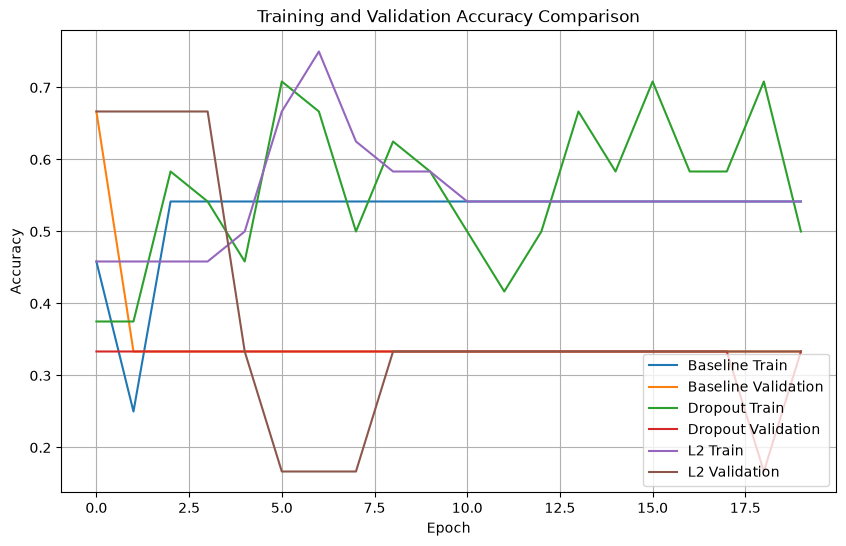

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(history_baseline.history["accuracy"], label="Baseline Train")
plt.plot(history_baseline.history["val_accuracy"], label="Baseline Validation")

plt.plot(history_dropout.history["accuracy"], label="Dropout Train")
plt.plot(history_dropout.history["val_accuracy"], label="Dropout Validation")

plt.plot(history_l2.history["accuracy"], label="L2 Train")
plt.plot(history_l2.history["val_accuracy"], label="L2 Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


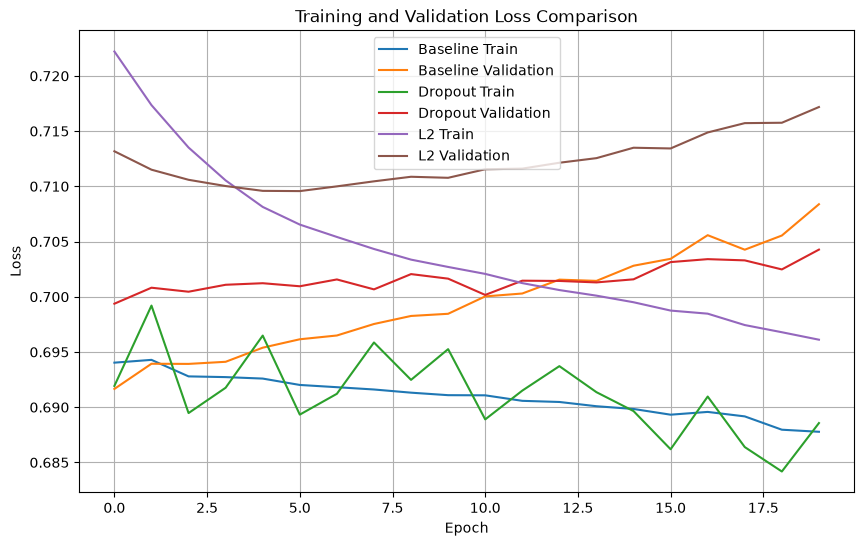

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(history_baseline.history["loss"], label="Baseline Train")
plt.plot(history_baseline.history["val_loss"], label="Baseline Validation")

plt.plot(history_dropout.history["loss"], label="Dropout Train")
plt.plot(history_dropout.history["val_loss"], label="Dropout Validation")

plt.plot(history_l2.history["loss"], label="L2 Train")
plt.plot(history_l2.history["val_loss"], label="L2 Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
test_sentences = np.array([
    "The movie was wonderful and enjoyable",
    "The film was boring and terrible"
])

test_vectors = vectorizer(test_sentences)

baseline_predictions = baseline_model.predict(test_vectors)
dropout_predictions = dropout_model.predict(test_vectors)
l2_predictions = l2_model.predict(test_vectors)

for i, sentence in enumerate(test_sentences):
    print("\nSentence:", sentence)
    print("Baseline prediction:", float(baseline_predictions[i][0]))
    print("Dropout prediction:", float(dropout_predictions[i][0]))
    print("L2 prediction:", float(l2_predictions[i][0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

Sentence: The movie was wonderful and enjoyable
Baseline prediction: 0.4866902530193329
Dropout prediction: 0.4989962577819824
L2 prediction: 0.4933163821697235

Sentence: The film was boring and terrible
Baseline prediction: 0.48416391015052795
Dropout prediction: 0.49342095851898193
L2 prediction: 0.4889284372329712
